In [73]:
import pandas as pd 
import numpy as np
import seaborn as sns

In [74]:
df = pd.read_csv('imputation_done.csv')

In [75]:
df.drop(columns=['area'],axis=1,inplace=True)

In [76]:
df.head()

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,signature global park 4,sector 36,0.82,7586.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,360.333333
1,flat,smart world gems,sector 89,0.95,8597.0,Carpet area: 1103 (102.47 sq.m.),2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0,552.500000
2,flat,breez global hill view,sohna road,0.32,5470.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,292.500000
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0,665.000000
4,flat,suncity avenue,sector 102,0.48,9023.0,Super Built up area 632(58.71 sq.m.)Carpet are...,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0,266.000000


In [77]:
df.drop(columns=['areaWithType','area_room_ratio'],axis=0,inplace=True)

In [78]:
train_df = df.drop(columns=['price_per_sqft','society'],axis=0)
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 36,0.82,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,sector 89,0.95,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,sohna road,0.32,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,sector 92,1.60,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,sector 102,0.48,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


luxury score

<Axes: ylabel='luxury_score'>

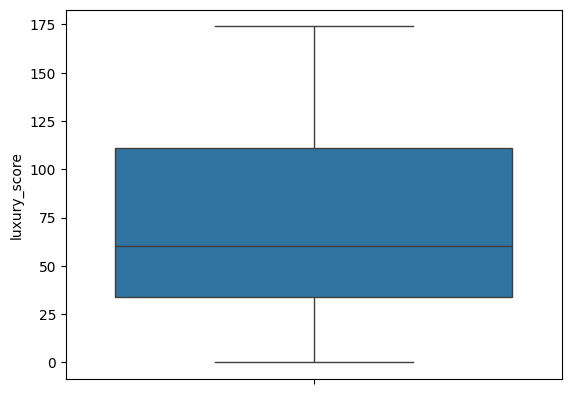

In [79]:
sns.boxplot(data =df['luxury_score'])

In [80]:
def categorize_luxury_score(score):
    if 0 <= score < 50:
        return 'Low'
    elif 50 <= score < 150:
        return 'Medium'
    elif 150 <= score <= 175:
        return 'High'
    else:
        return None

In [81]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury_score)

In [82]:
train_df

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 36,0.82,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,Low
1,flat,sector 89,0.95,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0,Low
2,flat,sohna road,0.32,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,Low
3,flat,sector 92,1.60,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0,High
4,flat,sector 102,0.48,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,flat,sector 84,0.37,2.0,2.0,1,5.0,Relatively New,532.0,0.0,0.0,0.0,0.0,0.0,0.0,73.0,Medium
3550,house,sector 109,6.00,5.0,5.0,3+,2.0,Relatively New,6228.0,1.0,1.0,1.0,1.0,0.0,0.0,160.0,High
3551,flat,sector 2,0.60,1.0,1.0,1,5.0,Moderately Old,665.0,0.0,0.0,0.0,0.0,0.0,1.0,67.0,Medium
3552,house,sector 43,15.50,5.0,6.0,3,3.0,Moderately Old,5490.0,1.0,1.0,1.0,1.0,0.0,0.0,76.0,Medium


floor num

<Axes: ylabel='floorNum'>

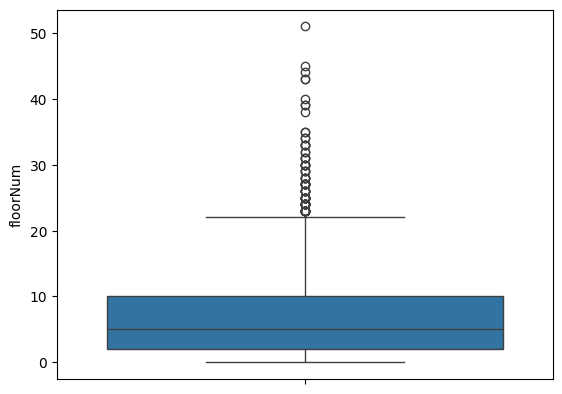

In [83]:
sns.boxplot(df['floorNum'])

In [84]:
def categorize_floor_num(floor):
    if 0 <= floor <= 2:
        return 'Low floor'
    elif 3 <= floor <= 10:
        return 'Medium floor'
    elif 11 <= floor <= 51:
        return 'High floor'
    else:
        return None

In [85]:
train_df['floorNum_Category'] = train_df['floorNum'].apply(categorize_floor_num)

In [86]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [87]:
train_df

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floorNum_Category
0,flat,sector 36,0.82,3.0,2.0,2,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,Low,Low floor
1,flat,sector 89,0.95,2.0,2.0,2,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,Low,Medium floor
2,flat,sohna road,0.32,2.0,2.0,1,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,Low,High floor
3,flat,sector 92,1.60,3.0,4.0,3+,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,High,Medium floor
4,flat,sector 102,0.48,2.0,2.0,1,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,High,Medium floor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,flat,sector 84,0.37,2.0,2.0,1,Relatively New,532.0,0.0,0.0,0.0,0.0,0.0,0.0,Medium,Medium floor
3550,house,sector 109,6.00,5.0,5.0,3+,Relatively New,6228.0,1.0,1.0,1.0,1.0,0.0,0.0,High,Low floor
3551,flat,sector 2,0.60,1.0,1.0,1,Moderately Old,665.0,0.0,0.0,0.0,0.0,0.0,1.0,Medium,Medium floor
3552,house,sector 43,15.50,5.0,6.0,3,Moderately Old,5490.0,1.0,1.0,1.0,1.0,0.0,0.0,Medium,Medium floor


In [88]:
df.drop(columns=['floorNum','luxury_score'],axis=0,inplace=True)

# Ordinal encoding
Ordinal encoding assigns integer numbers to each category.

In [89]:
from sklearn.preprocessing import OrdinalEncoder

#create a copy of the original dataframe
encoded_df = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    oe = OrdinalEncoder()
    encoded_df[col] = oe.fit_transform(encoded_df[[col]])
    print(oe.categories_)

x_label = encoded_df.drop(columns=['price'],axis=0)
y_label = encoded_df['price']


[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 10', 'sector 102', 'sector 103', 'sector 104',
       'sector 105', 'sector 106', 'sector 107', 'sector 108',
       'sector 109', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 30', 'sector 31', 'sector 33',
       'sector 36', 'sector 37', 'sector 37d', 'sector 38', 'sector 39',
       'sector 4', 'sector 40', 'sector 41', 'sector 43', 'sector 45',
       'sector 46', 'sector 47', 'sector 48', 'sector 49', 'sector 5',
       'sector 50', 'sector 51', 'sector 52', 'sector 53', 'sector 54',
       'sector 55', 'sector 56', 'sector 57', 'sector 58', 'sector 59',
       'sector 6', 'sector 60', 'sector 61', 'sector 62', 

In [90]:
x_label.head()

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floorNum_Category
0,0.0,36.0,3.0,2.0,2.0,1.0,850.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.0,95.0,2.0,2.0,2.0,1.0,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0
2,0.0,103.0,2.0,2.0,1.0,1.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,99.0,3.0,4.0,4.0,3.0,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0
4,0.0,5.0,2.0,2.0,1.0,3.0,582.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0


In [91]:
y_label.head()

0    0.82
1    0.95
2    0.32
3    1.60
4    0.48
Name: price, dtype: float64

# Feature Selection
we are trying 8 techniques to get the importance of columns though different techniques and at end we will average the importance and take the high important one 


technique 1 - Correlation Analysis


<Axes: >

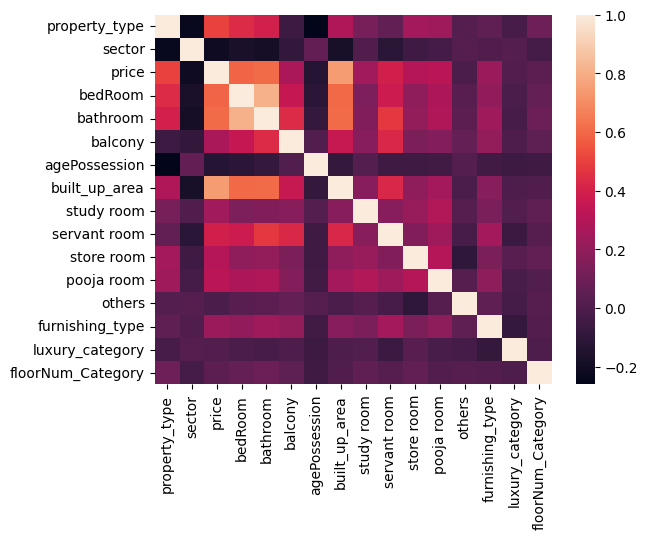

In [92]:
sns.heatmap(encoded_df.corr())

In [93]:
fi_df1 = encoded_df.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.212084
1,price,1.000000
2,bedRoom,0.591289
3,bathroom,0.609777
4,balcony,0.269637
5,agePossession,-0.134171
6,built_up_area,0.748574
7,study room,0.242955
8,servant room,0.391930
9,store room,0.305677


techinque 2 - Random Forest Feature importance

In [94]:
from sklearn.ensemble import RandomForestRegressor

#train a random forest regressor on encoded_df
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_label,y_label)

fi_df2 = pd.DataFrame({'feature':x_label.columns,
                       'rf_importance':rf.feature_importances_}
                       ).sort_values(by='rf_importance',ascending=False)
fi_df2

,feature,rf_importance
6,built_up_area,0.650541
1,sector,0.102670
0,property_type,0.100079
3,bathroom,0.025882
2,bedRoom,0.024041
8,servant room,0.019320
5,agePossession,0.014519
4,balcony,0.012576
12,furnishing_type,0.010604
7,study room,0.008383


techinque 3- gradient boosting feature importance


In [95]:
from sklearn.ensemble import GradientBoostingRegressor

#train a gradient boosting regressor on encoded_df
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(x_label,y_label)

fi_df3 = pd.DataFrame({'feature':x_label.columns,
                       'importance_gbr':gb.feature_importances_}
                       ).sort_values(by='importance_gbr',ascending=False)
fi_df3

,feature,importance_gbr
6,built_up_area,0.677569
1,sector,0.102877
0,property_type,0.098374
2,bedRoom,0.037718
3,bathroom,0.036251
8,servant room,0.023195
9,store room,0.010357
5,agePossession,0.004268
7,study room,0.003185
12,furnishing_type,0.002826


technique 4 - permutation importance

In [96]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

x_train_label, x_test_label, y_train_label, y_test_label = train_test_split(x_label, y_label, test_size=0.2, random_state=42)
rf.fit(x_train_label, y_train_label)

rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(x_train_label, y_train_label)

#calculate permutation importance for the random forest model
perm_importance = permutation_importance(rf_label, x_test_label, y_test_label, n_repeats=30, random_state=42)
 
#organise results into a dataframe
fi_df4 = pd.DataFrame({'feature':x_label.columns,
                       'importance_permutation':perm_importance.importances_mean}
                       ).sort_values(by='importance_permutation',ascending=False)
fi_df4

,feature,importance_permutation
6,built_up_area,0.736026
0,property_type,0.200636
1,sector,0.178881
8,servant room,0.021018
3,bathroom,0.019884
2,bedRoom,0.018006
5,agePossession,0.004970
9,store room,0.002150
14,floorNum_Category,0.000907
11,others,0.000792


Technique 5 Lasso

In [97]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

#standardize the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_label)

#train a lasso regression model on the standardized features
lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(x_scaled, y_label)


#extract coefficients and organize into a dataframe
fi_df5 = pd.DataFrame({'feature':x_label.columns,
                       'coefficient_LASSO':lasso.coef_}
                       ).sort_values(by='coefficient_LASSO',ascending=False)
fi_df5

,feature,coefficient_LASSO
6,built_up_area,1.489908
0,property_type,0.680381
3,bathroom,0.278293
9,store room,0.162200
7,study room,0.117472
8,servant room,0.109652
12,furnishing_type,0.096992
10,pooja room,0.046096
4,balcony,0.000000
1,sector,-0.000000


Technique 6 -RFE
best feature selection technique

In [98]:
from sklearn.feature_selection import RFE

#initialize a base estimator
estimator = RandomForestRegressor()

#apply RFE with the random forest regressor as the base estimator
selector_label = RFE(estimator, n_features_to_select= x_label.shape[1],step=1)
selector_label = selector_label.fit(x_label, y_label)

#get the selected features based on rfe
selected_features = x_label.columns[selector_label.support_]

#extract the coefficients and organize into a dataframe
selected_coefficients = selector_label.estimator_.feature_importances_

fi_df6 = pd.DataFrame({'feature':x_label.columns,
                       'importance_RFE':selected_coefficients}
                        ).sort_values(by='importance_RFE',ascending=False)
fi_df6

,feature,importance_RFE
6,built_up_area,0.649365
1,sector,0.104701
0,property_type,0.097499
2,bedRoom,0.028882
3,bathroom,0.023882
8,servant room,0.019263
5,agePossession,0.014464
4,balcony,0.013234
12,furnishing_type,0.010293
7,study room,0.008065


Technique 7 - linear regression weights

In [99]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(x_label, y_label)

fi_df7 = pd.DataFrame({'feature':x_label.columns,
                       'coefficient_lin':lin_reg.coef_}
                          ).sort_values(by='coefficient_lin',ascending=False)
fi_df7

,feature,coefficient_lin
0,property_type,1.747110
9,store room,0.712247
7,study room,0.461125
8,servant room,0.353614
12,furnishing_type,0.295505
10,pooja room,0.203530
3,bathroom,0.194489
13,luxury_category,0.096246
2,bedRoom,0.013481
6,built_up_area,0.001244


Technique 8 SHAP

In [100]:
import shap

#compute shap values for the random forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_label, y_label)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(x_label)

#summing the absolute shap values for each feature and organizing into a dataframe
shap_importance = np.abs(shap_values).mean(axis=0)

fi_df8 = pd.DataFrame({'feature':x_label.columns,
                       'SHap score':shap_importance}
).sort_values(by='SHap score',ascending=False)
fi_df8

,feature,SHap score
6,built_up_area,1.255552
0,property_type,0.473110
1,sector,0.383640
3,bathroom,0.112811
8,servant room,0.095577
2,bedRoom,0.049731
4,balcony,0.040327
12,furnishing_type,0.027405
5,agePossession,0.027312
14,floorNum_Category,0.024505


Merging all dfs

In [101]:
final = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')
final

,corr_coeff,rf_importance,importance_gbr,importance_permutation,coefficient_LASSO,importance_RFE,coefficient_lin,SHap score
feature,,,,,,,,
sector,-0.212084,0.102670,0.102877,0.178881,-0.000000,0.104701,-0.002416,0.383640
bedRoom,0.591289,0.024041,0.037718,0.018006,0.000000,0.028882,0.013481,0.049731
bathroom,0.609777,0.025882,0.036251,0.019884,0.278293,0.023882,0.194489,0.112811
balcony,0.269637,0.012576,0.001899,-0.000432,0.000000,0.013234,-0.057962,0.040327
agePossession,-0.134171,0.014519,0.004268,0.004970,-0.000000,0.014464,-0.001590,0.027312
built_up_area,0.748574,0.650541,0.677569,0.736026,1.489908,0.649365,0.001244,1.255552
study room,0.242955,0.008383,0.003185,-0.018027,0.117472,0.008065,0.461125,0.019533
servant room,0.391930,0.019320,0.023195,0.021018,0.109652,0.019263,0.353614,0.095577
store room,0.305677,0.008329,0.010357,0.002150,0.162200,0.007736,0.712247,0.017123


In [102]:
#normalize the feature importance scores in final by dividing each column by the sum of that column
final = final.divide(final.sum(axis=0),axis=1)

In [103]:
#area,floornum,luxury_score --- IGNORE ---

In [104]:
final[['rf_importance','importance_gbr','importance_permutation','importance_RFE','SHap score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area        0.713479
sector               0.143120
bathroom             0.034063
bedRoom              0.028652
servant room         0.027272
agePossession        0.011038
balcony              0.009921
store room           0.007954
furnishing_type      0.005692
floorNum_Category    0.005506
luxury_category      0.004940
pooja room           0.003634
study room           0.002445
others               0.002284
dtype: float64

#highest built_up_area
and lowest is others , pooja room,study room so we can remove it 
but we still have to prove it that we can remove that 
we will train a random forest with both having these features and after removing this if both corresponds to same value then we can delete

In [105]:
x_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floorNum_Category
0,0.0,36.0,3.0,2.0,2.0,1.0,850.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.0,95.0,2.0,2.0,2.0,1.0,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0
2,0.0,103.0,2.0,2.0,1.0,1.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,99.0,3.0,4.0,4.0,3.0,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0
4,0.0,5.0,2.0,2.0,1.0,3.0,582.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,0.0,90.0,2.0,2.0,1.0,3.0,532.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
3550,1.0,12.0,5.0,5.0,4.0,3.0,6228.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
3551,0.0,23.0,1.0,1.0,1.0,0.0,665.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0
3552,1.0,44.0,5.0,6.0,3.0,0.0,5490.0,1.0,1.0,1.0,1.0,0.0,0.0,2.0,2.0


In [106]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, x_label, y_label, cv=5, scoring='r2')

In [107]:
scores.mean()

np.float64(0.8193190510339333)

In [109]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf,x_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [110]:
scores.mean()

np.float64(0.8196500940616491)

as they are same means these columns are not usefull

In [108]:
export_df = x_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [111]:
export_df.to_csv('post_feature_selection.csv', index=False)